In [1]:
%matplotlib inline

# Playing with Loss Functions

Some useful PyTorch links

* PyTorch loss functions: https://pytorch.org/docs/stable/nn.html
  * torch.nn.MSELoss(size_average=None, reduce=None, reduction='mean')
  * torch.nn.CrossEntropyLoss(weight=None, size_average=None, ignore_index=-100, reduce=None, reduction='mean')
  * torch.nn.KLDivLoss(size_average=None, reduce=None, reduction='mean')
  * torch.nn.BCELoss(weight=None, size_average=None, reduce=None, reduction='mean')
  * torch.nn.TripletMarginLoss(margin=1.0, p=2.0, eps=1e-06, swap=False, size_average=None, reduce=None, reduction='mean')
  
To start, lets look at the sum of squared error and then cross entropy

## Sum of Squared Error

Swing with the notation! ;-)

* $E_S = \frac{1}{2}{ (d - y)^2 }$
 * $d \in \Re$ is the label
 * $y \in \Re$ is the network output 
 * lets assume $y = \sigma(v) = \frac{1}{1 + e^{-v}}$ (a sigmoid, whose derivative is $\sigma(v)(1-\sigma(v))$)

Lets take the derivative of this function 

* $\frac{\partial E_S}{\partial w_i} = \frac{\partial E}{\partial e} \frac{\partial e}{\partial y} \frac{\partial y}{\partial v} \frac{\partial v}{\partial w_i}$

where

* $\frac{\partial E}{\partial e} = \frac{\partial}{\partial e}(\frac{1}{2}e^2) = e$
* $\frac{\partial e}{\partial y} = \frac{\partial}{\partial y}(d - y) = -1$ 
* $\frac{\partial y}{\partial v} = \sigma(v) (1 - \sigma(v))$
* $\frac{\partial v}{\partial w_i} = x_i$

which gives us

* $(-1)(d-y)(\sigma(v) (1 - \sigma(v))) x_i = (-1)(d-y)(y*(1-y)) x_i$

ok, next, look at cross entropy for a comparison

## Cross Entropy

Lets consider the binary case of cross entropy

* $E_C = (-1)\Big( t \ln(y) + (1-t) \ln(1-y) \Big)$

Lets differentiate (down to our weight, assuming a sigmoid, $\sigma(v)=\frac{1}{1+e^{-v}}$, whose derivative is $\sigma(v)(1-\sigma(v))$)

$\frac{\partial E_C}{\partial w_i} = \frac{\partial}{\partial w_i}\Big( (-1)(t \ln(y)) \Big) + \frac{\partial}{\partial w_i} \Big( (-1)((1-t) \ln(1-y)) \Big)$

$= -t \frac{\partial}{\partial w_i} ln(y) - (1-t) \frac{\partial}{\partial w_i} ln(1-y)$

$= \frac{-t}{\sigma} \frac{\partial \sigma}{\partial v} \frac{\partial v}{\partial w_i} - \frac{1-t}{1-\sigma} \frac{\partial (1-\sigma)}{\partial v} \frac{\partial v}{\partial w_i}$

$= \frac{-t}{\sigma} (\sigma (1-\sigma)) x_i - \frac{1-t}{1-\sigma} (-\sigma (1-\sigma)) x_i$

$= -t (1-\sigma) x_i + (1-t) (\sigma) x_i$

$= -t x_i + t \sigma x_i + \sigma x_i - t \sigma x_i$

$= -t x_i + \sigma x_i$

$= x_i \Big( \sigma - t \Big)$

$= x_i \Big( y - t \Big)$

# Lets plot this

Network predicted values
[1.   0.95 0.9  0.85 0.8  0.75 0.7  0.65 0.6  0.55 0.5  0.45 0.4  0.35
 0.3  0.25 0.2  0.15 0.1  0.05]


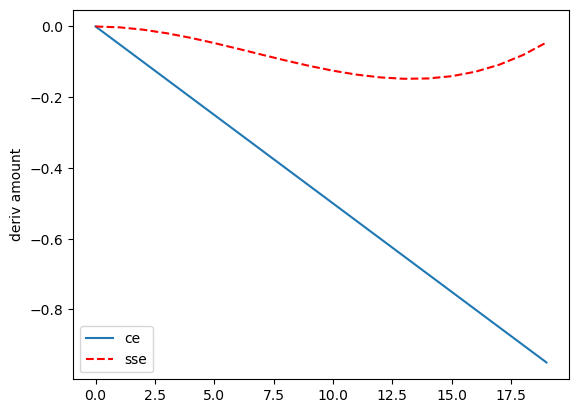

In [2]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

def CrossEntropy(x,y,t):
    return x * (y - t)

def Sse(x,y,t):
    return (-1) * (t - y) * (y * (1-y)) * x

x = 1 # some input (keeping it fixed below)
t = 1 # our target (keeping it fixed below)
y = np.arange(1.0,0,-0.05) # different possible net outputs

print( "Network predicted values" )
print( y )

ce = CrossEntropy(x,y,t)
se = Sse(x,y,t)

plt.plot(ce)
plt.plot(se,'--r')
plt.ylabel('deriv amount')
plt.legend(['ce','sse'])
plt.show()